# Day 3 - Classical Machine Learning Models

Data Science for Life Scientists

Today we will build a supervised classification workflow using Cell Painting profiles as features and ToxCast cell-based assay activity as the label to predict. In this notebook, each compound is one sample, the Cell Painting measurements are the input variables, and one selected assay is the biological activity target.

The goal is not to build the perfect model. The goal is to practise a clean machine-learning protocol: define a target, split the data, train a simple reference model, train a stronger model, evaluate it honestly, and interpret the result.

## Topics

- Select a biological activity / mode-of-action endpoint to predict
- Compare train/test data splitting strategies
- Train an XGBoost boosted-tree classifier
- Optimise XGBoost hyperparameters
- Evaluate performance with confusion matrices, accuracy, precision, recall, ROC AUC / AUROC, balanced accuracy, and F1-score
- Interpret model results with permutation importance and SHAP / Shapley values

## Learning outcomes

By the end of this notebook, you should be able to:

- Describe the workflow of supervised machine learning
- Train and evaluate an XGBoost classifier on biological datasets
- Explain why data imbalance changes how we interpret model performance
- Experiment with XGBoost parameters and connect those changes to performance
- Use feature-importance and SHAP plots to discuss what the model has learned

## Notebook workflow

1. Load the Cell Painting, compound metadata, and ToxCast tables.
2. Merge the tables so each compound has both features and labels.
3. Choose one assay endpoint to predict.
4. Make a stratified train/test split.
5. Create a simple majority-class reference.
6. Train an XGBoost classifier.
7. Tune a small set of XGBoost hyperparameters.
8. Explore thresholds, feature importance, SHAP values, and high-scoring compounds.

## 1. Setup

This notebook uses **XGBoost as the only classifier implementation**. We still use pandas for tables, matplotlib/seaborn for plots, and scikit-learn for splitting, scoring, feature selection, and cross-validation because `XGBClassifier` follows the scikit-learn estimator API.

Useful documentation links:

- pandas file loading: [`read_parquet`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_parquet.html), [`read_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)
- pandas joins: [`DataFrame.merge`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)
- scikit-learn splitting and tuning: [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html), [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- XGBoost model API: [`XGBClassifier`](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) and the [XGBoost parameter guide](https://xgboost.readthedocs.io/en/stable/parameter.html)
- model interpretation: [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html), [`shap.TreeExplainer`](https://shap.readthedocs.io/en/stable/generated/shap.TreeExplainer.html), [`shap.plots.beeswarm`](https://shap.readthedocs.io/en/stable/generated/shap.plots.beeswarm.html), and [`shap.plots.waterfall`](https://shap.readthedocs.io/en/latest/generated/shap.plots.waterfall.html)

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline


from xgboost import XGBClassifier

import shap

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
MODEL_FAMILY = "XGBoost classifier"

print(f"Model implementation: {MODEL_FAMILY}")

Model implementation: XGBoost classifier


## 2. Load and merge the datasets

We will use three tables:

- `df_cell_painting`: Cell Painting profiles for 1,086 reference compounds.
- `df_compounds_infos`: Compound metadata.
- `df_toxcast_cellbased`: ToxCast cell-based binary activity labels.

These tables cannot be joined directly because each data source uses a different compound identifier. The Cell Painting table names compounds with `Metadata_compound`, the compound metadata table uses `PREFERRED_NAME` and `OASIS_ID`, and the ToxCast labels are keyed by `OASIS_ID`. We therefore need the metadata table as a bridge between the Cell Painting profiles and the ToxCast assay labels.

The merge path is:

`Metadata_compound` -> `PREFERRED_NAME` -> `OASIS_ID` -> ToxCast assay labels

Key functions and arguments:

- [`pd.read_parquet`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_parquet.html): loads columnar Parquet files efficiently, which is useful for high-dimensional Cell Painting features.
- [`pd.read_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html): loads the compound metadata table from a comma-separated text file.
- [`DataFrame.merge`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html): joins tables; `how="left"` keeps all Cell Painting rows during the lookup step, `how="inner"` keeps only compounds with labels, and `validate="many_to_one"` checks that the join keys behave as expected.

### Why this merge matters

The model can only learn from compounds that have both Cell Painting features and ToxCast labels. The metadata table acts like a lookup table: it translates compound names into the `OASIS_ID` used by the assay tables.

In [102]:
# Paths are written relative to this notebook folder.
DATA_DIR = Path("../../inputs")

# Cell Painting features and ToxCast labels are stored as Parquet files.
# Compound metadata is a CSV file, so we use read_csv for that table.
df_cell_painting = pd.read_parquet(DATA_DIR / "level6_axiom_selected_features.parquet")
df_toxcast_cellbased = pd.read_parquet(DATA_DIR / "toxcast_cytotox_binary.parquet")
df_compounds_infos = pd.read_csv(DATA_DIR / "v5_oasis_03Sept2024_simple.csv")

print(f"Cell Painting profiles: {df_cell_painting.shape}")
print(f"ToxCast cell-based labels: {df_toxcast_cellbased.shape}")
print(f"Compound metadata: {df_compounds_infos.shape}")

Cell Painting profiles: (1086, 4439)
ToxCast cell-based labels: (963, 39)
Compound metadata: (1494, 20)


In [103]:
# A few compound names are repeated in the metadata table. Dropping duplicates prevents
# one Cell Painting row from expanding into multiple rows during the merge.
df_compounds_infos_unique = df_compounds_infos.drop_duplicates(subset="PREFERRED_NAME").copy()

# First merge: attach OASIS_ID values to the Cell Painting rows by matching names.
# validate="many_to_one" checks that each compound name maps to at most one metadata row.
df_cell_painting_compounds_infos = df_cell_painting.merge(
    df_compounds_infos_unique,
    how="left",
    left_on="Metadata_compound",
    right_on="PREFERRED_NAME",
    validate="many_to_one",
)

# Second merge: keep only compounds that also have ToxCast cell-based labels.
df_ml = df_cell_painting_compounds_infos.merge(
    df_toxcast_cellbased,
    how="inner",
    on="OASIS_ID",
    validate="many_to_one",
)

print(f"Cell Painting compounds: {len(df_cell_painting):,}")
print(f"Cell Painting compounds with OASIS_ID: {df_cell_painting_compounds_infos['OASIS_ID'].notna().sum():,}")
print(f"Compounds merged with ToxCast cell-based labels: {len(df_ml):,}")

df_ml[["Metadata_compound", "PREFERRED_NAME", "OASIS_ID"]].head()

Cell Painting compounds: 1,086
Cell Painting compounds with OASIS_ID: 791
Compounds merged with ToxCast cell-based labels: 551


,Metadata_compound,PREFERRED_NAME,OASIS_ID
0,"1,4-Dibromobenzene","1,4-Dibromobenzene",OASIS548
1,"1,4-Dichlorobenzene","1,4-Dichlorobenzene",OASIS292
2,"1,6-Dichlorohexane","1,6-Dichlorohexane",OASIS287
3,1-Naphthaleneacetic acid,1-Naphthaleneacetic acid,OASIS370
4,"2,6-Diaminopyridine","2,6-Diaminopyridine",OASIS381


## 3. Choose the assay / mode of action to predict

A supervised model needs a target variable. Here, each ToxCast column is a binary endpoint: `1` means the compound was active in that assay, and `0` means it was inactive. We can treat a chosen assay as the biological activity or mode-of-action endpoint to predict from Cell Painting profiles.

Not every assay is equally useful for a first model. If an assay has very few active compounds, the model may mostly learn to predict the majority class. The code below summarises each possible target so we can choose one with enough active and inactive examples.

In [104]:
# Feature columns are the Cell Painting measurements used as model inputs.
feature_cols = [col for col in df_ml.columns if col.startswith("Feature_")]

# Every ToxCast column except OASIS_ID is a possible binary target.
toxcast_assay_cols = [col for col in df_toxcast_cellbased.columns if col != "OASIS_ID"]

# For binary labels, the sum is the number of active compounds.
target_summary = df_ml[toxcast_assay_cols].agg(["sum", "count"]).T
target_summary = target_summary.rename(columns={"sum": "n_active", "count": "n_tested"})
target_summary["n_inactive"] = target_summary["n_tested"] - target_summary["n_active"]
target_summary["active_fraction"] = target_summary["n_active"] / target_summary["n_tested"]

# Keep targets with enough examples from both classes for a first teaching model.
eligible_targets = target_summary.query("n_active >= 25 and n_inactive >= 25").sort_values(
    ["active_fraction", "n_tested"], ascending=[False, False]
)

print(f"Number of Cell Painting features: {len(feature_cols):,}")
print(f"Number of possible ToxCast cell-based targets: {len(toxcast_assay_cols):,}")
eligible_targets.head(20)

Number of Cell Painting features: 4,434
Number of possible ToxCast cell-based targets: 38


,n_active,n_tested,n_inactive,active_fraction
cell_type__22Rv1,74.0,150.0,76.0,0.493333
tissue__prostate,74.0,150.0,76.0,0.493333
cell_type__HEK293,158.0,485.0,327.0,0.325773
cell_type__T47D,55.0,186.0,131.0,0.295699
tissue__vascular,37.0,150.0,113.0,0.246667
cell_type__umbilical_vein_endothelium_and_peripheral_blood_mononuclear_cells,36.0,150.0,114.0,0.240000
cell_type__HepG2,130.0,548.0,418.0,0.237226
tissue__liver,130.0,548.0,418.0,0.237226
cell_type__ERR-HEK293T,109.0,485.0,376.0,0.224742
cell_type__PGC/ERR_HEK293T,109.0,485.0,376.0,0.224742


### Your turn

Choose an assay from the table above. Try to pick one with at least 25 active and 25 inactive compounds.

Questions to discuss:

- Search what the assay measures biologically.
- Is the target balanced or imbalanced?
- Why might a highly imbalanced target make accuracy misleading?

,class,n_compounds,fraction
0,inactive,418,0.762774
1,active,130,0.237226


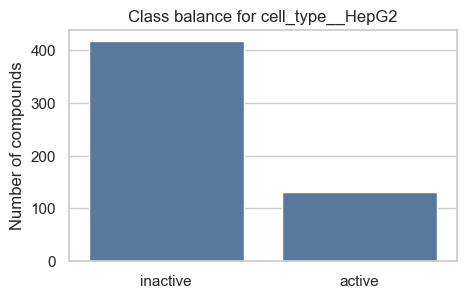

In [116]:
# Change this value to try a different prediction task.
TARGET = "cell_type__HepG2"

if TARGET not in toxcast_assay_cols:
    raise ValueError(f"{TARGET} is not a valid ToxCast cell-based assay column.")

# X contains the input features; y contains the binary activity label.
df_model = df_ml.dropna(subset=[TARGET]).copy()
X = df_model[feature_cols].copy()
y = df_model[TARGET].astype(int)

# Class balance tells us how many active and inactive examples the model sees.
class_balance = (
    y.value_counts()
    .rename(index={0: "inactive", 1: "active"})
    .rename_axis("class")
    .reset_index(name="n_compounds")
)
class_balance["fraction"] = class_balance["n_compounds"] / class_balance["n_compounds"].sum()

display(class_balance)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(data=class_balance, x="class", y="n_compounds", ax=ax, color="#4C78A8")
ax.set_title(f"Class balance for {TARGET}")
ax.set_xlabel("")
ax.set_ylabel("Number of compounds")
plt.show()

## 4. Train/test splitting strategies

A model should be evaluated on data it did not see during training. For classification problems, stratified splitting is usually safer than a simple random split because it preserves the active/inactive class proportions in both train and test sets.

The classical ML notebook used a train/test split. But sometimes a **validation set** can be used.

- Training set: used to update neural-network weights.
- Validation set: used to compare parameter/hyperparameter choices, detect overfitting, and choose a final model.
- Test set: held back until the end as an independent estimate of performance.

Key function: [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

Important arguments:

- `test_size=0.25`: keeps 25% of compounds aside for final evaluation.
- `random_state=RANDOM_STATE`: makes the split reproducible for teaching and debugging.
- `stratify=y`: keeps the active/inactive proportions similar in the train and test sets.

In [107]:
TEST_SIZE = 0.25

def summarise_split(strategy_name, stratify_labels):
    """Return the class balance produced by one splitting strategy."""
    _, _, y_train_tmp, y_test_tmp = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_labels,
    )
    return {
        "strategy": strategy_name,
        "train_n": len(y_train_tmp),
        "test_n": len(y_test_tmp),
        "train_active_fraction": y_train_tmp.mean(),
        "test_active_fraction": y_test_tmp.mean(),
    }

split_comparison = pd.DataFrame(
    [
        summarise_split("random", None),
        summarise_split("stratified", y),
    ]
)

split_comparison

,strategy,train_n,test_n,train_active_fraction,test_active_fraction
0,random,411,137,0.238443,0.233577
1,stratified,411,137,0.238443,0.233577


### Quick question

Look at the active fractions in the train and test sets. Which split would you trust more for this dataset, and why?

## 5. Feature selection protocol

Cell Painting datasets often contain thousands of measurements. Many features can be noisy, redundant, or almost constant across compounds. Reducing the feature set can make the notebook faster and can help the XGBoost model focus on more informative variation.

Common possibilities include:

- Variance filtering: keep features that vary most across compounds.
- Correlation filtering: remove one feature from pairs that are almost duplicates.
- Univariate tests: keep features individually associated with the target.
- Model-based selection: keep features ranked highly by a fitted model.

Here we use variance filtering because it is simple, fast, and does not look at the label. Important: we calculate variance on `X_train` only. The test set must stay untouched until final evaluation, otherwise information from the test set leaks into model training.

Key function: [`DataFrame.var`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.var.html), which computes feature-wise variance so we can keep the most variable Cell Painting measurements.

In [108]:
# This is the split we will use for model training and final test-set evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

N_FEATURES = min(500, X_train.shape[1])
feature_variance = X_train.var(axis=0).sort_values(ascending=False)
selected_features = feature_variance.head(N_FEATURES).index.tolist()

X_train_model = X_train[selected_features]
X_test_model = X_test[selected_features]

print(f"Training compounds: {len(X_train_model):,}")
print(f"Test compounds: {len(X_test_model):,}")
print(f"Selected features: {len(selected_features):,}")

Training compounds: 411
Test compounds: 137
Selected features: 500


## Evaluation helpers

For imbalanced biological datasets, no single metric tells the whole story.

- Accuracy: fraction of correct predictions.
- Precision: among predicted actives, how many are truly active?
- Recall: among true actives, how many did we find?
- Balanced accuracy: average recall across the two classes.
- F1-score: harmonic mean of precision and recall.
- ROC AUC / AUROC: how well the model ranks active compounds above inactive compounds across thresholds.

Key functions and URLs:

- [`XGBClassifier.predict_proba`](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier.predict_proba): returns one score per class; here column `1` is the active-class score.
- scikit-learn's [classification metrics guide](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics): overview of common classification scores.
- [`roc_auc_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html): calculates the area under the ROC curve from continuous scores.

In [109]:
def positive_class_scores(model, X_values):
    """Return XGBoost's active-class probability score for each compound."""
    return model.predict_proba(X_values)[:, 1]


def evaluate_predictions(y_true, y_score, threshold=0.5, label="model"):
    """Convert scores to labels at one threshold and calculate common metrics."""
    y_pred = (y_score >= threshold).astype(int)
    return pd.Series(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc_auroc": roc_auc_score(y_true, y_score) if pd.Series(y_true).nunique() == 2 else np.nan,
        },
        name=label,
    )


def evaluate_model(model, X_values, y_true, threshold=0.5, label="model"):
    return evaluate_predictions(
        y_true=y_true,
        y_score=positive_class_scores(model, X_values),
        threshold=threshold,
        label=label,
    )

## 6. Start with a simple reference

Before fitting XGBoost, we create a majority-class reference. This is not a second machine-learning implementation; it is just a sanity check that asks, "what happens if we always predict the class that is most common in the training set?"

The reference uses the active-class fraction in the training set as a constant score for every test compound. At the default threshold of `0.5`, that gives the majority-class prediction. If XGBoost cannot beat this reference, we should be suspicious of the workflow or the prediction task.

In [111]:
# The same score is assigned to every compound, so this is a reference line rather than a fitted model.
baseline_score = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_metrics = evaluate_predictions(
    y_test,
    baseline_score,
    threshold=0.5,
    label="Majority-class reference",
)

baseline_metrics.to_frame().T

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Majority-class reference,0.5,0.766423,0.5,0.0,0.0,0.0,0.5


### Quick question

If the reference accuracy is high but recall is zero, what does that tell you about the target and the class balance?

## 7. Train an XGBoost boosted-tree classifier

XGBoost is a gradient boosted decision tree algorithm. It trains many small trees in sequence, where each new tree focuses on errors made by the previous trees. In this notebook, XGBoost is the only fitted classifier implementation.

Key functions and arguments:

- [`XGBClassifier`](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier): scikit-learn-compatible XGBoost classifier.
- [`fit`](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier.fit): trains the model on `X_train_model` and `y_train`.
- [`predict_proba`](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier.predict_proba): returns active/inactive probability scores for held-out compounds.
- [`n_estimators`](https://xgboost.readthedocs.io/en/stable/parameter.html): number of boosting rounds / trees.
- [`max_depth`](https://xgboost.readthedocs.io/en/stable/parameter.html): maximum depth of each tree; deeper trees can learn more complex interactions but can overfit.
- [`learning_rate`](https://xgboost.readthedocs.io/en/stable/parameter.html): step size for each tree's contribution; smaller values usually need more trees.
- [`subsample`](https://xgboost.readthedocs.io/en/stable/parameter.html): fraction of compounds sampled for each tree.
- [`colsample_bytree`](https://xgboost.readthedocs.io/en/stable/parameter.html): fraction of features sampled for each tree.
- [`scale_pos_weight`](https://xgboost.readthedocs.io/en/stable/parameter.html): increases the weight of the positive class when active compounds are rare.

In [112]:
# Weight the active class more when active compounds are rarer than inactive compounds.
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)


def make_classifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
):
    return XGBClassifier(
        objective="binary:logistic",
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )


# Fit the XGBoost model on the training set only.
boost_model = make_classifier(scale_pos_weight=scale_pos_weight)
boost_model.fit(X_train_model, y_train)

model_metrics = pd.concat(
    [
        baseline_metrics,
        evaluate_model(boost_model, X_test_model, y_test, label=MODEL_FAMILY),
    ],
    axis=1,
).T

model_metrics

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Majority-class reference,0.5,0.766423,0.500000,0.0,0.0000,0.000000,0.500000
XGBoost classifier,0.5,0.824818,0.690179,0.7,0.4375,0.538462,0.752083


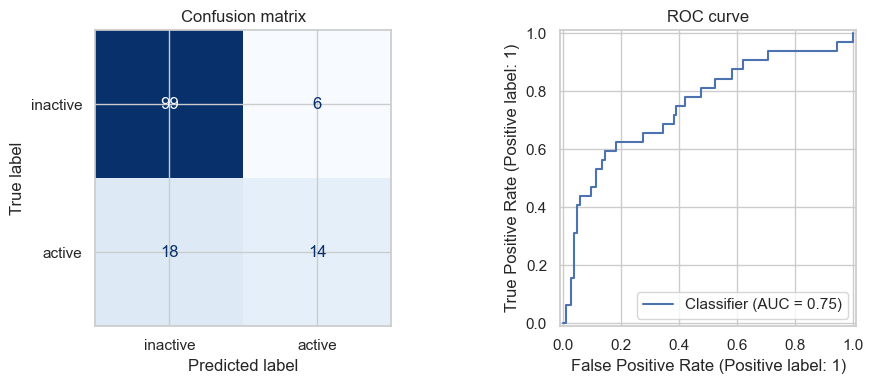

In [113]:
# Scores are continuous; labels are made by applying a threshold.
y_test_score = positive_class_scores(boost_model, X_test_model)
y_train_score = positive_class_scores(boost_model, X_train_model)
y_test_pred = (y_test_score >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix: counts of true/false positives and negatives at threshold 0.5.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["inactive", "active"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion matrix")

# ROC curve: ranking performance across all possible thresholds.
RocCurveDisplay.from_predictions(y_test, y_test_score, ax=axes[1])
axes[1].set_title("ROC curve")

plt.tight_layout()
plt.show()

### Your turn: change the model

Try changing the values below. Re-run the next cell and compare the metrics.

Guiding questions:

- What happens when `max_depth` is larger?
- What happens when `learning_rate` is smaller?
- What happens when `subsample` or `colsample_bytree` is smaller?
- Can you improve recall without destroying precision?
- Do different parameters help more for some assays than others?

In [114]:
PLAY_N_ESTIMATORS = 100
PLAY_MAX_DEPTH = 3
PLAY_LEARNING_RATE = 0.05
PLAY_SUBSAMPLE = 0.9
PLAY_COLSAMPLE_BYTREE = 0.8

student_model = make_classifier(
    n_estimators=PLAY_N_ESTIMATORS,
    max_depth=PLAY_MAX_DEPTH,
    learning_rate=PLAY_LEARNING_RATE,
    subsample=PLAY_SUBSAMPLE,
    colsample_bytree=PLAY_COLSAMPLE_BYTREE,
    scale_pos_weight=scale_pos_weight,
)
student_model.fit(X_train_model, y_train)

pd.concat(
    [
        evaluate_model(boost_model, X_test_model, y_test, label="Default XGBoost model"),
        evaluate_model(student_model, X_test_model, y_test, label="Your parameter choice"),
    ],
    axis=1,
).T

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Default XGBoost model,0.5,0.824818,0.690179,0.700000,0.4375,0.538462,0.752083
Your parameter choice,0.5,0.802920,0.675893,0.608696,0.4375,0.509091,0.759524


## 8. Hyperparameter optimisation

Manual experimentation is useful for intuition, but we can also ask scikit-learn to try a small grid of XGBoost parameter values. The score used here is ROC AUC because it evaluates ranking performance across thresholds.

Key functions and arguments:

- [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html): tries every parameter combination in `param_grid` using cross-validation.
- `estimator=search_model`: the XGBoost model that will be fitted repeatedly.
- `param_grid=param_grid`: the XGBoost parameter values to test.
- `scoring="roc_auc"`: choose the parameter set with the best mean validation AUROC.
- `refit=True`: train the best parameter combination again on the full training set.
- [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html): keeps class proportions similar across cross-validation folds.

In [115]:
# Three folds keeps the search quick for teaching while still testing each parameter set
# on multiple validation splits.
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
)

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [2, 4],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
}

# refit=True retrains the best parameter combination on the full training set.
grid_search = GridSearchCV(
    estimator=search_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv3,
    n_jobs=1,
    refit=True,
)

grid_search.fit(X_train_model, y_train)

grid_results = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
grid_results[["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10)

,rank_test_score,mean_test_score,std_test_score,params
8,1,0.845671,0.030099,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
6,2,0.844113,0.030523,"{'learning_rate': 0.03, 'max_depth': 4, 'n_est..."
14,3,0.843012,0.022775,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti..."
10,4,0.842300,0.033692,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
2,5,0.839438,0.026731,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est..."
12,6,0.839176,0.025326,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti..."
0,7,0.838550,0.028929,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est..."
4,8,0.837458,0.031595,"{'learning_rate': 0.03, 'max_depth': 4, 'n_est..."
13,9,0.836117,0.012497,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti..."
9,10,0.835288,0.042181,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."


In [88]:
# The tuned XGBoost model is evaluated once on the held-out test set.
best_model = grid_search.best_estimator_
best_test_score = positive_class_scores(best_model, X_test_model)
best_train_score = positive_class_scores(best_model, X_train_model)

pd.concat(
    [
        baseline_metrics,
        evaluate_model(boost_model, X_test_model, y_test, label="Initial XGBoost model"),
        evaluate_predictions(y_test, best_test_score, label="Tuned XGBoost model"),
    ],
    axis=1,
).T

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Majority-class reference,0.5,0.778689,0.500000,0.000000,0.000000,0.000000,0.500000
Initial XGBoost model,0.5,0.729508,0.521442,0.285714,0.148148,0.195122,0.583626
Tuned XGBoost model,0.5,0.745902,0.505458,0.250000,0.074074,0.114286,0.570370


### Quick question

Did hyperparameter optimisation improve every metric, or mainly one metric? Why might improving ROC AUC not always improve recall at a fixed threshold of 0.5?

## 9. Thresholds and biological priorities

The model returns a probability-like score. The default classification threshold is 0.5, but exploring the predicted probabilities can changes precision and recall.

In toxicology, the best threshold depends on the question. If the goal is early screening, high recall may be useful. If follow-up experiments are expensive, high precision may matter more. This is why we can inspect several thresholds and probability values.

Be careful of not fixing a definitive threshold on the test set as it would result in data leakage.  

In [91]:
# Lower thresholds usually predict more actives; higher thresholds are more conservative.
thresholds = [0.2, 0.35, 0.5, 0.65, 0.8]

threshold_results = pd.concat(
    [
        evaluate_predictions(
            y_test,
            best_test_score,
            threshold=threshold,
            label=f"threshold={threshold}",
        )
        for threshold in thresholds
    ],
    axis=1,
).T

threshold_results

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
threshold=0.2,0.20,0.655738,0.527096,0.258065,0.296296,0.275862,0.57037
threshold=0.35,0.35,0.721311,0.529435,0.294118,0.185185,0.227273,0.57037
threshold=0.5,0.50,0.745902,0.505458,0.250000,0.074074,0.114286,0.57037
threshold=0.65,0.65,0.770492,0.507992,0.333333,0.037037,0.066667,0.57037
threshold=0.8,0.80,0.778689,0.500000,0.000000,0.000000,0.000000,0.57037


## 10. Interpret the model

Model interpretation asks: which features were useful for the prediction, which compounds were scored as most likely active, and what feature values pushed an individual prediction up or down?

We will use two complementary approaches:

- Permutation importance: shuffle one feature at a time and measure how much held-out ROC AUC gets worse. This is model-agnostic and uses the test set.
- SHAP / Shapley values: explain XGBoost predictions by assigning each feature a contribution to the model output. This is especially useful for comparing global patterns with a single-compound explanation.

Key functions and URLs:

- [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html): reports `importances_mean`, `importances_std`, and the raw repeated importances.
- [`shap.TreeExplainer`](https://shap.readthedocs.io/en/stable/generated/shap.TreeExplainer.html): SHAP explainer optimised for tree-based models such as XGBoost.
- [`shap.plots.beeswarm`](https://shap.readthedocs.io/en/stable/generated/shap.plots.beeswarm.html): global view of which features push predictions higher or lower across compounds.
- [`shap.plots.waterfall`](https://shap.readthedocs.io/en/latest/generated/shap.plots.waterfall.html): local view of how features move one prediction from the baseline output to the final output.

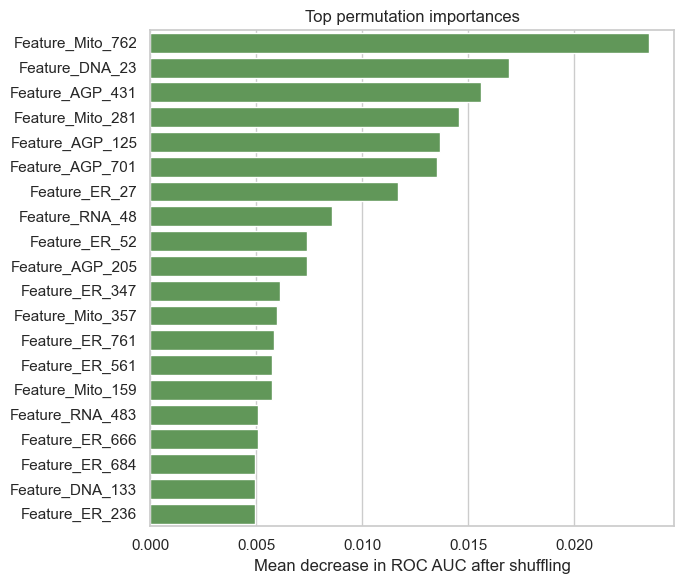

,feature,importance_mean,importance_std
189,Feature_Mito_762,0.023522,0.009150
251,Feature_DNA_23,0.016894,0.005461
480,Feature_AGP_431,0.015595,0.004138
476,Feature_Mito_281,0.014555,0.004572
166,Feature_AGP_125,0.013645,0.003323
342,Feature_AGP_701,0.013515,0.009761
320,Feature_ER_27,0.011696,0.002486
52,Feature_RNA_48,0.008577,0.006938
372,Feature_ER_52,0.007407,0.000955
391,Feature_AGP_205,0.007407,0.002295


In [97]:
# Measure importance on the held-out test set, not the training set.
perm_importance = permutation_importance(
    best_model,
    X_test_model,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = pd.DataFrame(
    {
        "feature": selected_features,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)

top_importance = importance_df.head(20)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=top_importance, x="importance_mean", y="feature", ax=ax, color="#59A14F")
ax.set_title("Top permutation importances")
ax.set_xlabel("Mean decrease in ROC AUC after shuffling")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

top_importance

In [98]:
# Keep whichever compound annotation columns are available in this dataset.
compound_columns = [
    col
    for col in [
        "Metadata_compound",
        "OASIS_ID",
        "Metadata_compound_target",
        "Metadata_compound_pathway",
    ]
    if col in df_model.columns
]

# Add the model score beside the known test-set label so we can inspect compounds.
prediction_table = df_model.loc[X_test.index, compound_columns].copy()
prediction_table["true_label"] = y_test.values
prediction_table["predicted_activity_score"] = best_test_score
prediction_table["predicted_label_0_5"] = (best_test_score >= 0.5).astype(int)

prediction_table.sort_values("predicted_activity_score", ascending=False).head(15)

,Metadata_compound,OASIS_ID,Metadata_compound_target,Metadata_compound_pathway,true_label,predicted_activity_score,predicted_label_0_5
176,Diphenhydramine,OASIS1006,Bacterial; Endogenous Metabolite; Histamine Re...,Anti-infection; GPCR/G Protein; Immunology/Inf...,0,0.723370,1
27,Actinomycin D,OASIS1499,Antibiotic; Apoptosis; Autophagy; Bacterial; D...,Anti-infection; Apoptosis; Autophagy; Cell Cyc...,0,0.694784,1
33,Alpidem,OASIS1490,GABA Receptor,Membrane Transporter/Ion Channel; Neuronal Sig...,1,0.665783,1
271,Imipramine,OASIS030,Apoptosis; Autophagy; Serotonin Transporter,Apoptosis; Autophagy; Neuronal Signaling,0,0.644837,1
298,Leflunomide,OASIS1536,Bacterial; Dihydroorotate Dehydrogenase; Endog...,Anti-infection; Metabolic Enzyme/Protease,1,0.632579,1
69,Benzonatate,OASIS1521,Sodium Channel,Membrane Transporter/Ion Channel,0,0.607310,1
194,Erlotinib,OASIS1472,Autophagy; EGFR,Autophagy; JAK/STAT Signaling; Protein Tyrosin...,0,0.548770,1
355,Nifedipine,OASIS036,Autophagy; Calcium Channel,Autophagy; Membrane Transporter/Ion Channel; N...,0,0.543993,1
418,Prochloraz,OASIS456,Androgen Receptor; Aryl Hydrocarbon Receptor; ...,Anti-infection; Immunology/Inflammation; Vitam...,1,0.495319,0
264,Ibudilast,OASIS1368,Phosphodiesterase (PDE),Metabolic Enzyme/Protease,1,0.470659,0


### Bonus: Shapley / SHAP interpretation

SHAP values are based on Shapley values from cooperative game theory. For this notebook, the practical idea is simple: each Cell Painting feature gets a contribution for each compound. Positive SHAP values push the XGBoost output toward "active"; negative SHAP values push it toward "inactive".

We sample at most 100 test compounds to keep the plot quick. The beeswarm plot gives a global view, while the waterfall plot explains the highest-scoring test compound.

If the `shap` package is missing, install it in the same environment as this notebook and re-run this section.

SHAP values explain the model output scale: active-class probability


,feature,mean_abs_shap
285,Feature_RNA_156,0.021498
449,Feature_RNA_411,0.018551
189,Feature_Mito_762,0.018354
187,Feature_Mito_437,0.016597
342,Feature_AGP_701,0.015382
444,Feature_Mito_636,0.014862
340,Feature_DNA_295,0.013359
480,Feature_AGP_431,0.013131
476,Feature_Mito_281,0.013038
251,Feature_DNA_23,0.011990


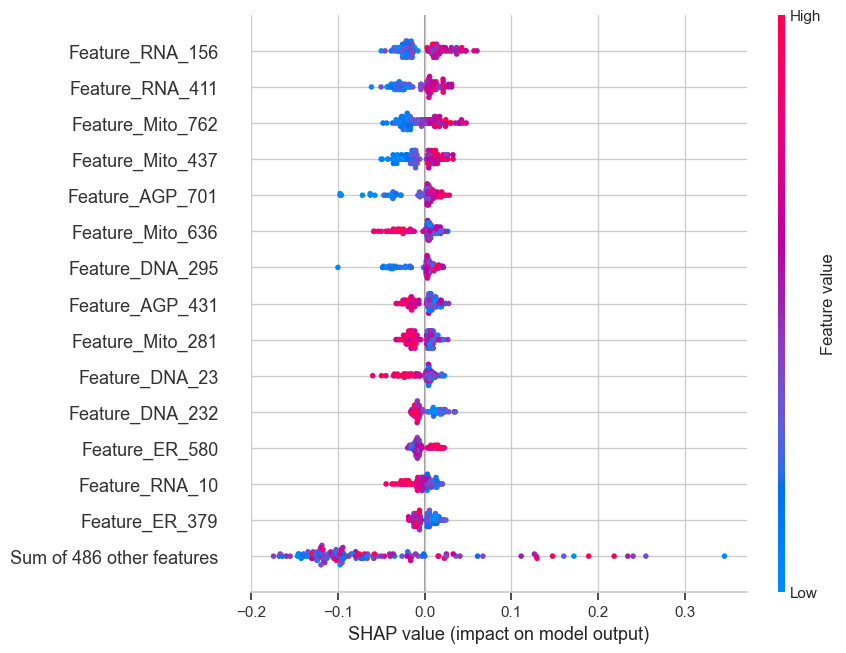

,Metadata_compound,OASIS_ID,Metadata_compound_target,Metadata_compound_pathway,true_label,predicted_activity_score,predicted_label_0_5
176,Diphenhydramine,OASIS1006,Bacterial; Endogenous Metabolite; Histamine Re...,Anti-infection; GPCR/G Protein; Immunology/Inf...,0,0.72337,1


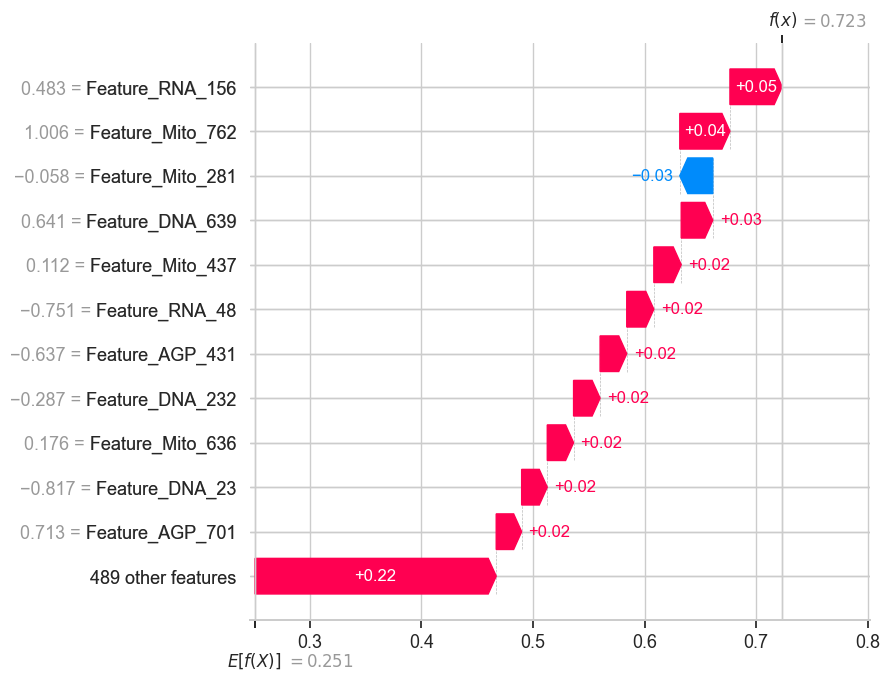

In [101]:
# Use all available data
background = X_train_model
shap_sample = X_test_model.copy()

# Highest-scoring compound for the local waterfall plot
compound_to_explain = prediction_table["predicted_activity_score"].idxmax()

# SHAP explainer
shap_explainer = shap.TreeExplainer(best_model, data=background, model_output="probability")
shap_output_scale = "active-class probability"

# SHAP values for all test rows
shap_values = shap_explainer(shap_sample)

# For binary classification, keep the positive class if SHAP returns 3D output
if getattr(shap_values, "values", np.array([])).ndim == 3:
    shap_values = shap_values[:, :, 1]

# Global feature importance on all test data
shap_importance = (
    pd.DataFrame({
        "feature": shap_sample.columns,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
)

print(f"SHAP values explain the model output scale: {shap_output_scale}")
display(shap_importance.head(15))

shap.plots.beeswarm(shap_values, max_display=15)

# Local explanation for the top predicted compound
compound_position = shap_sample.index.get_loc(compound_to_explain)
display(prediction_table.loc[[compound_to_explain]])
shap.plots.waterfall(shap_values[compound_position], max_display=12)

### Interpretation questions

- Do the top Cell Painting features come from one channel or several channels?
- Do permutation importance and SHAP rank similar features highly?
- For the waterfall plot compound, which features push the model toward active or inactive?

## Bonus: cross-validation

A single train/test split can be noisy, especially with small biological datasets. Cross-validation repeats the train/test idea across several folds and reports the average performance.

For a rigorous cross-validation workflow, preprocessing and feature selection should happen inside the cross-validation loop. The pipeline below does that while keeping the classifier step as XGBoost.

Key functions and URLs:

- [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): chains preprocessing, feature selection, and the XGBoost classifier so each fold is fitted independently.
- [`SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html): fills missing feature values inside each fold.
- [`VarianceThreshold`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html): removes constant or near-constant features inside each fold.
- [`SelectKBest`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html): keeps the top `k` features according to a univariate score.
- [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html): evaluates the full pipeline across folds and returns one score per fold.

In [117]:
# SelectKBest needs k to be no larger than the number of available features.
K_FEATURES_FOR_CV = min(N_FEATURES, X.shape[1])

# Use the full target vector only to set the class-imbalance weight for this CV exercise.
cv_scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

# The pipeline refits imputation, filtering, feature selection, and XGBoost inside each fold.
cv_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold()),
        ("feature_selector", SelectKBest(score_func=f_classif, k=K_FEATURES_FOR_CV)),
        ("classifier", make_classifier(scale_pos_weight=cv_scale_pos_weight)),
    ]
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc_auroc": "roc_auc",
}

cv_scores = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv5,
    scoring=scoring,
    n_jobs=1,
)

cv_summary = pd.DataFrame(cv_scores).filter(like="test_")
cv_summary.columns = cv_summary.columns.str.replace("test_", "", regex=False)
cv_summary.agg(["mean", "std"]).T.sort_values("mean", ascending=False)

,mean,std
roc_auc_auroc,0.842441,0.032362
accuracy,0.819349,0.011771
balanced_accuracy,0.719946,0.041016
precision,0.645814,0.021503
f1,0.578357,0.059069
recall,0.530769,0.099555


### Final reflection

Write a short answer to each prompt:

- Did Cell Painting features predict your selected assay better than the baseline?
- What do you think of the performance of your model?
- What would you try next to improve the model?

### Bonus:

Relaunch the protocol to predict the cytotoxicity "cell_type__HepG2" (or "tissue__liver") from the toxcast_cytotox_binary.parquet